In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# choosing stock example "CIB"
ticker = "COMI.CA"

# downloading data during one year
data = yf.download(ticker, start="2025-01-01", end="2025-12-31")

data.head()

/tmp/ipykernel_6079/17716843.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,COMI.CA,COMI.CA,COMI.CA,COMI.CA,COMI.CA
Date,,,,,
2025-01-02,73.202156,73.553776,72.739495,72.637710,839510
2025-01-05,73.128128,73.563030,73.100370,73.202155,778429
2025-01-06,72.961571,73.470500,72.693227,73.128129,988286
2025-01-08,73.192902,73.831375,72.545180,72.961571,2704606
2025-01-09,71.712387,73.794360,71.712387,73.192899,575703


In [4]:
#Log Returns
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# deleting missing values
data.dropna(inplace=True)

data.head()

Price,Close,High,Low,Open,Volume,Log_Return
Ticker,COMI.CA,COMI.CA,COMI.CA,COMI.CA,COMI.CA,
Date,,,,,,
2025-01-05,73.128128,73.563030,73.100370,73.202155,778429,-0.001012
2025-01-06,72.961571,73.470500,72.693227,73.128129,988286,-0.002280
2025-01-08,73.192902,73.831375,72.545180,72.961571,2704606,0.003166
2025-01-09,71.712387,73.794360,71.712387,73.192899,575703,-0.020435
2025-01-12,70.564995,71.888204,70.352168,71.712391,1885655,-0.016129


In [5]:
# Daily
mean_daily = data['Log_Return'].mean()
std_daily = data['Log_Return'].std()

# Annual
mean_annual = mean_daily * 252
std_annual = std_daily * np.sqrt(252)

# Skewness & Kurtosis
skewness = data['Log_Return'].skew()
kurtosis = data['Log_Return'].kurt()


print("Mean Daily:", mean_daily)
print("Std Daily:", std_daily)
print("Mean Annual:", mean_annual)
print("Std Annual:", std_annual)
print("Skewness:", skewness)
print("Kurtosis:", kurtosis)

Mean Daily: 0.0012225103626503123
Std Daily: 0.015336005599456234
Mean Annual: 0.3080726113878787
Std Annual: 0.24345154152753143
Skewness: -0.21690277370119587
Kurtosis: 4.444336316745511


<Figure size 640x480 with 0 Axes>

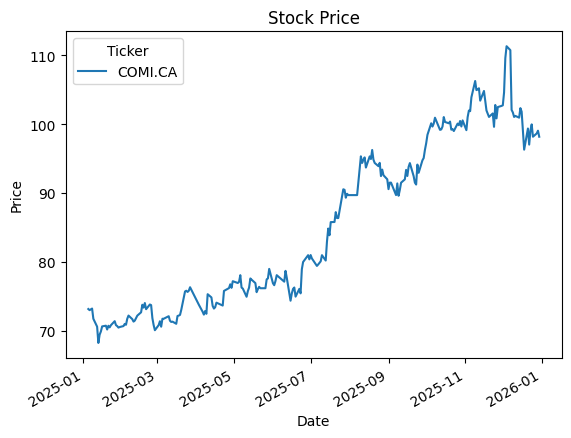

In [6]:
plt.figure()
data['Close'].plot(title="Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

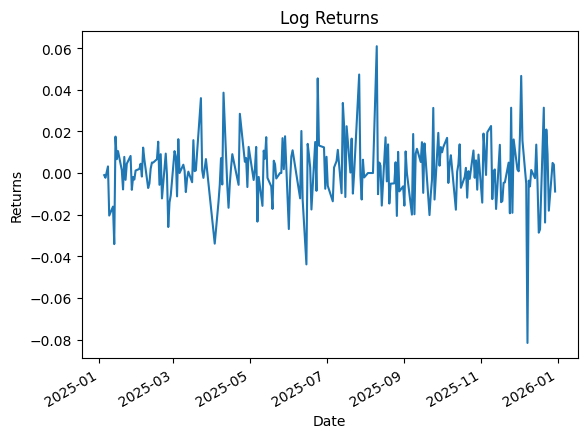

In [7]:
plt.figure()
data['Log_Return'].plot(title="Log Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.show()

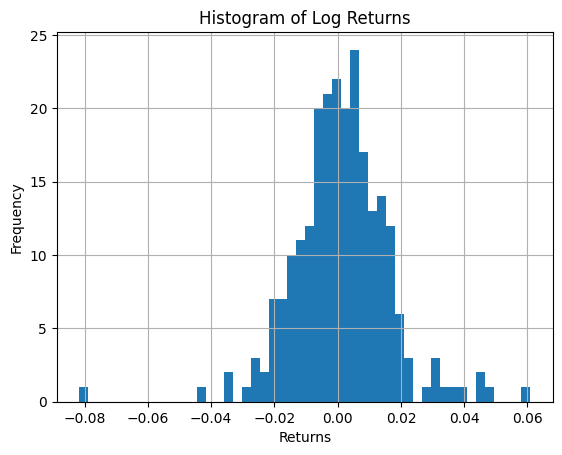

In [8]:
plt.figure()
data['Log_Return'].hist(bins=50)
plt.title("Histogram of Log Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.show()

In [9]:
if std_annual > 0.3:
    print("The stock is highly volatile")
else:
    print("The stock has low/moderate volatility")

if abs(skewness) < 0.5:
    print("Returns are approximately normal")
else:
    print("Returns are not normally distributed")

if kurtosis > 3:
    print("There are extreme risks (fat tails)")
else:
    print("No significant extreme risks")

The stock has low/moderate volatility
Returns are approximately normal
There are extreme risks (fat tails)


In [10]:
tickers = ["COMI.CA", "ETEL.CA", "TMGH.CA"]

for t in tickers:
    data = yf.download(t, start="2025-01-01", end="2025-12-31")
    returns = np.log(data['Close'] / data['Close'].shift(1))
    returns = returns.dropna()

    print(f"\nStock: {t}")
    print("Volatility:", returns.std())

/tmp/ipykernel_6079/493499490.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


Stock: COMI.CA
Volatility: Ticker
COMI.CA    0.015336
dtype: float64



/tmp/ipykernel_6079/493499490.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_6079/493499490.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(t, start="2025-01-01", end="2025-12-31")



Stock: ETEL.CA
Volatility: Ticker
ETEL.CA    0.018727
dtype: float64


[*********************100%***********************]  1 of 1 completed


Stock: TMGH.CA
Volatility: Ticker
TMGH.CA    0.018637
dtype: float64


In [17]:
import yfinance as yf
import numpy as np

ticker = "COMI.CA"

data = yf.download(ticker, start="2025-01-01", end="2025-12-31")

# تأكد إن فيه بيانات
print(data.head())

# حساب Log Return
data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))

# حذف القيم الناقصة
data.dropna(inplace=True)

# حساب mu و sigma
mu = data['Log_Return'].mean()
sigma = data['Log_Return'].std()

print("mu:", mu)
print("sigma:", sigma)

/tmp/ipykernel_6079/893193002.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker        COMI.CA    COMI.CA    COMI.CA    COMI.CA  COMI.CA
Date                                                           
2025-01-02  73.202156  73.553776  72.739495  72.637710   839510
2025-01-05  73.128128  73.563030  73.100370  73.202155   778429
2025-01-06  72.961571  73.470500  72.693227  73.128129   988286
2025-01-08  73.192902  73.831375  72.545180  72.961571  2704606
2025-01-09  71.712387  73.794360  71.712387  73.192899   575703
mu: 0.0012225103626503123
sigma: 0.015336005599456234


In [18]:
import numpy as np

S0 = data['Close'].iloc[-1]  # آخر سعر
T = 15
dt = 1

prices = [S0]

for t in range(T):
    Z = np.random.normal()
    S_prev = prices[-1]

    S_next = (
        S_prev
        + mu * S_prev * dt
        + sigma * S_prev * np.sqrt(dt) * Z
        + 0.5 * (sigma**2) * S_prev * dt * (Z**2 - 1)
    )

    prices.append(S_next)

prices

[Ticker
 COMI.CA    98.162804
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    97.447132
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    96.497579
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    96.760692
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    97.18378
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    96.477203
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    96.731749
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    96.120005
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    98.06978
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    96.426074
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    94.656151
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    94.515767
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    94.894709
 Name: 2025-12-30 00:00:00, dtype: float64,
 Ticker
 COMI.CA    95.332531
 Name: 202

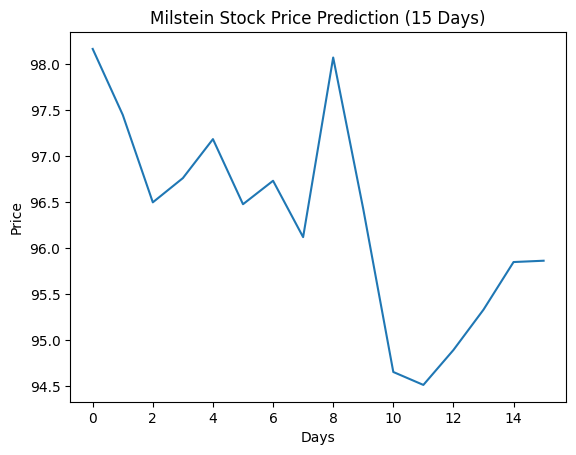

In [19]:
import matplotlib.pyplot as plt

plt.plot(prices)
plt.title("Milstein Stock Price Prediction (15 Days)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

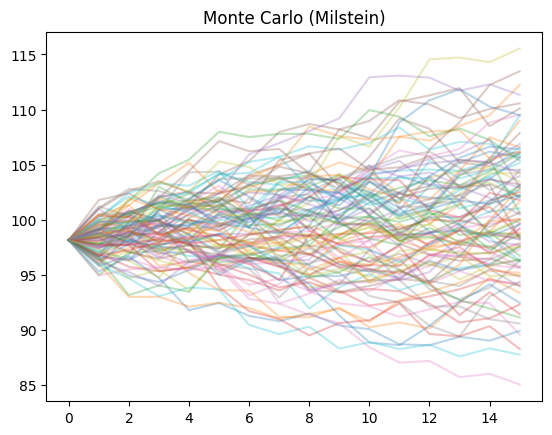

In [20]:
simulations = 100
T = 15
dt = 1

all_paths = []

for i in range(simulations):
    prices = [S0]

    for t in range(T):
        Z = np.random.normal()
        S_prev = prices[-1]

        S_next = (
            S_prev
            + mu * S_prev * dt
            + sigma * S_prev * np.sqrt(dt) * Z
            + 0.5 * (sigma**2) * S_prev * dt * (Z**2 - 1)
        )

        prices.append(S_next)

    all_paths.append(prices)

for path in all_paths:
    plt.plot(path, alpha=0.3)

plt.title("Monte Carlo (Milstein)")
plt.show()

In [21]:
euler_prices = [S0]

for t in range(T):
    Z = np.random.normal()
    S_prev = euler_prices[-1]

    S_next = S_prev + mu * S_prev * dt + sigma * S_prev * np.sqrt(dt) * Z
    euler_prices.append(S_next)

In [22]:
milstein_prices = [S0]

for t in range(T):
    Z = np.random.normal()
    S_prev = milstein_prices[-1]

    S_next = (
        S_prev
        + mu * S_prev * dt
        + sigma * S_prev * np.sqrt(dt) * Z
        + 0.5 * (sigma**2) * S_prev * dt * (Z**2 - 1)
    )

    milstein_prices.append(S_next)

In [23]:
import numpy as np

euler_prices = np.array(euler_prices)
milstein_prices = np.array(milstein_prices)

avg_prices = (euler_prices + milstein_prices) / 2

print(avg_prices)

[[ 98.16280365]
 [100.02486595]
 [101.36318287]
 [ 99.98663543]
 [100.51192533]
 [101.73105178]
 [100.74492396]
 [101.98605824]
 [103.44806836]
 [104.53854381]
 [106.20360581]
 [106.72869182]
 [106.84770457]
 [105.58933282]
 [106.54000093]
 [108.35200509]]


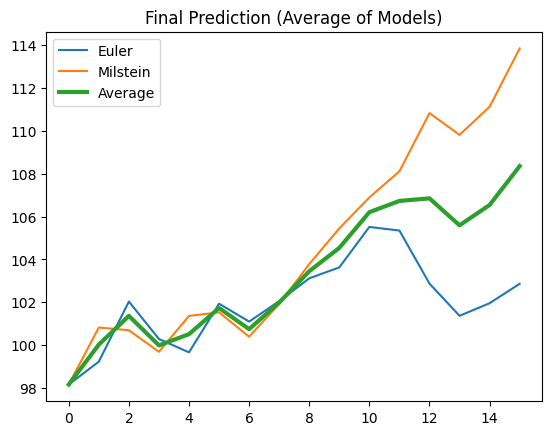

In [24]:
import matplotlib.pyplot as plt

plt.plot(euler_prices, label="Euler")
plt.plot(milstein_prices, label="Milstein")
plt.plot(avg_prices, label="Average", linewidth=3)

plt.legend()
plt.title("Final Prediction (Average of Models)")
plt.show()

In [26]:
import numpy as np

avg_euler = np.mean(euler_prices)

print("Average Euler Prediction:", avg_euler)

Average Euler Prediction: 101.94440693254899
